# **TAASIM**


---


# **Task 4 : Remapping Porto Dataset to Casablanca & Map Matching**

*ID2 , ENSAH. 2025/2026 - Enseignant : Mohamed El Marouani*


##**Partie 1 : Zone Remapping**

### Objectif :
- Apply zone remapping (Porto →
Casablanca arrondissements) in
PySpark.
- Visualize on OSM map.

### Output :
- Transformed dataset :

        trip_id
        origin_zone
        destination_zone
        Polyline_casa
        timestamp
        CALL_TYPE
        TAXI_ID
        DAY_TYPE
        

- Casablanca Map :    

        points
        trips
        zones

# **Résultat du notebook précedent :**
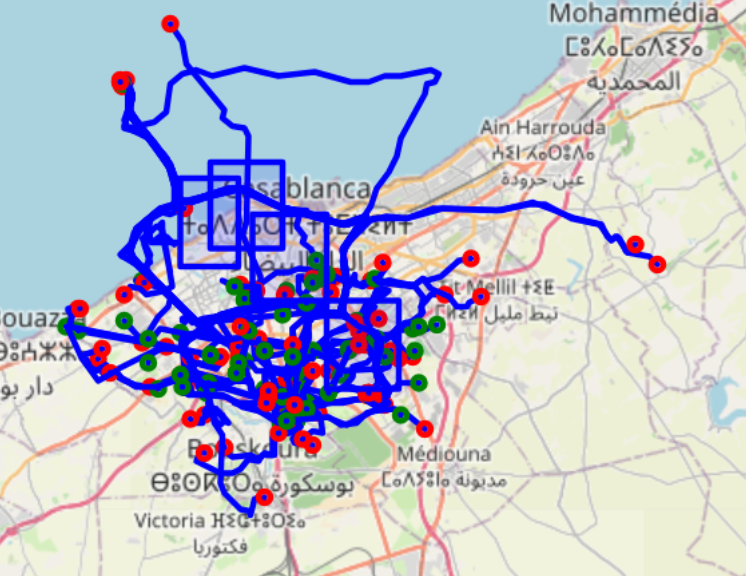

## **Step 0 — Setup environnement**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 0

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

# Démarrer Spark
spark = SparkSession.builder \
    .appName("Casablanca Remapping") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark ready")

Spark ready


## **Step 1 — Load Porto Dataset**

In [ ]:
# CELL 1

df = spark.read.csv("/content/drive/MyDrive/train.csv", header=True, inferSchema=True)

df.printSchema()
df.show(5, truncate=False)

df.count()

root
 |-- TRIP_ID: long (nullable = true)
 |-- CALL_TYPE: string (nullable = true)
 |-- ORIGIN_CALL: integer (nullable = true)
 |-- ORIGIN_STAND: integer (nullable = true)
 |-- TAXI_ID: integer (nullable = true)
 |-- TIMESTAMP: integer (nullable = true)
 |-- DAY_TYPE: string (nullable = true)
 |-- MISSING_DATA: boolean (nullable = true)
 |-- POLYLINE: string (nullable = true)

+-------------------+---------+-----------+------------+--------+----------+--------+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

1710670

## **Step 2 — Cleaning**



- POLYLINE vide ([])


In [ ]:
# CELL 2

df_clean = df.filter(col("POLYLINE") != "[]")


print("Rows after cleaning:", df_clean.count())

Rows after cleaning: 1704769


## **Step 3 — POLYLINE Parsing**

- transformer texte → structure exploitable

- POLYLINE est de type string , donc on doit la transformer en liste de points,
chaque point = [lon, lat]

In [ ]:
df.select("POLYLINE").printSchema()

root
 |-- POLYLINE: string (nullable = true)



In [ ]:
# CELL 3

schema = ArrayType(ArrayType(DoubleType()))

df_parsed = df_clean.withColumn(
    "polyline_array",
    from_json(col("POLYLINE"), schema)
)

df_parsed.select("polyline_array").show(3, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## **Step 4 — Extract origin & destination GPS**

- Objectif : éviter d’exploser toute la trajectoire

- On récupère :

      premier point → origine
      dernier point → destination

- Résultat :

      origin_lon, origin_lat
      destination_lon, destination_lat

In [ ]:
# CELL 4

df_points = df_parsed \
    .withColumn("origin", col("polyline_array")[0]) \
    .withColumn("destination", element_at(col("polyline_array"), -1)) \
    .withColumn("origin_lon", col("origin")[0]) \
    .withColumn("origin_lat", col("origin")[1]) \
    .withColumn("destination_lon", col("destination")[0]) \
    .withColumn("destination_lat", col("destination")[1])

df_points.select("origin_lon", "origin_lat").show(5)
df_points.describe()

+----------+----------+
|origin_lon|origin_lat|
+----------+----------+
| -8.618643| 41.141412|
| -8.639847| 41.159826|
| -8.612964| 41.140359|
| -8.574678| 41.151951|
| -8.645994|  41.18049|
+----------+----------+
only showing top 5 rows


DataFrame[summary: string, TRIP_ID: string, CALL_TYPE: string, ORIGIN_CALL: string, ORIGIN_STAND: string, TAXI_ID: string, TIMESTAMP: string, DAY_TYPE: string, POLYLINE: string, origin_lon: string, origin_lat: string, destination_lon: string, destination_lat: string]

##**Step 5 : Bounding Box Porto**
- connaître limites GPS Porto

In [ ]:
# CELL 5
quantiles = df_points.selectExpr(
    "percentile(origin_lat, 0.01) as lat_min",
    "percentile(origin_lat, 0.99) as lat_max",
    "percentile(origin_lon, 0.01) as lon_min",
    "percentile(origin_lon, 0.99) as lon_max"
).collect()[0]

porto_lat_min = quantiles["lat_min"]
porto_lat_max = quantiles["lat_max"]
porto_lon_min = quantiles["lon_min"]
porto_lon_max = quantiles["lon_max"]

##**Step 6 : Bounding Box Casablanca**
- définir zone cible

In [ ]:
# CELL 6

# Coordonnées pour Casablanca (Zone Urbaine terrestre)
casa_lat_min = 33.47  # Limite Sud (Bouskoura / Lissasfa)
casa_lat_max = 33.63  # Limite Nord (Juste avant la mer / Sidi Bernoussi)
casa_lon_min = -7.73  # Limite Ouest (Dar Bouazza / Hay Hassani)
casa_lon_max = -7.51  # Limite Est (Tit Mellil / Sidi Moumen)


## **Step 7 — GPS Porto → Casablanca**

- Objectif : déplacer les trajets

    Pour chaque point :

    origin → origin_casa
    destination → destination_casa

- Résultat :

    origin_lat_casa, origin_lon_casa
    destination_lat_casa, destination_lon_casa

- maintenant tout est dans Casablanca

In [ ]:
# CELL 7

df_transformed = df_points \
.withColumn("origin_lat_casa",
    ((col("origin_lat") - porto_lat_min) / (porto_lat_max - porto_lat_min))
    * (casa_lat_max - casa_lat_min) + casa_lat_min
) \
.withColumn("origin_lon_casa",
    ((col("origin_lon") - porto_lon_min) / (porto_lon_max - porto_lon_min))
    * (casa_lon_max - casa_lon_min) + casa_lon_min
) \
.withColumn("destination_lat_casa",
    ((col("destination_lat") - porto_lat_min) / (porto_lat_max - porto_lat_min))
    * (casa_lat_max - casa_lat_min) + casa_lat_min
) \
.withColumn("destination_lon_casa",
    ((col("destination_lon") - porto_lon_min) / (porto_lon_max - porto_lon_min))
    * (casa_lon_max - casa_lon_min) + casa_lon_min
)

df_transformed.select("origin_lat_casa", "origin_lon_casa").show(5)

+------------------+------------------+
|   origin_lat_casa|   origin_lon_casa|
+------------------+------------------+
| 33.47358186302411|-7.605103263440015|
| 33.53568772528933|-7.645960901781492|
| 33.47003035477138|-7.594160491880815|
| 33.50912730032251| -7.52038782910295|
|33.605382280402196|  -7.6578054548321|
+------------------+------------------+
only showing top 5 rows


## **Step 8 — Création de la grille (4×4)**

- Objectif : construire 16 zones

- calculer la taille d'une zone :
lat_step
lon_step

- Limite : pas réaliste puisque en réalité chaque zone a sa propre taille


In [ ]:
# CELL 8

lat_step = (casa_lat_max - casa_lat_min) / 4
lon_step = (casa_lon_max - casa_lon_min) / 4

## **Step 9 — Mapping GPS → zones**
- Objectif : transformer coordonnées en zones

    - Pour **origine** :


            (origin_lat_casa, origin_lon_casa) → origin_zone

    - Pour **destination** :
            
            (destination_lat_casa, destination_lon_casa) → destination_zone

- Résultat :

        trip_id → origin_zone, destination_zone

In [ ]:
# CELL 9

df_zones = df_transformed \
.withColumn("origin_row",
    floor((col("origin_lat_casa") - casa_lat_min) / lat_step)
) \
.withColumn("origin_col",
    floor((col("origin_lon_casa") - casa_lon_min) / lon_step)
) \
.withColumn("destination_row",
    floor((col("destination_lat_casa") - casa_lat_min) / lat_step)
) \
.withColumn("destination_col",
    floor((col("destination_lon_casa") - casa_lon_min) / lon_step)
) \
.withColumn("origin_zone",
    col("origin_row") * 4 + col("origin_col") + 1
) \
.withColumn("destination_zone",
    col("destination_row") * 4 + col("destination_col") + 1
)

## **Step 10 — Gestion des cas limites**

- Objectif :

   - éviter erreurs

- Points hors bounding box :
   - clamp (ramener dans limite)
ou supprimer
- zones invalides :
    - vérifier entre 1 et 16

In [ ]:
# CELL 10

df_zones = df_zones \
.withColumn("origin_zone", \
    when(col("origin_zone") > 16, 16)\
    .when(col("origin_zone") < 1, 1)\
    .otherwise(col("origin_zone")))\
.withColumn("destination_zone", \
    when(col("destination_zone") > 16, 16)\
    .when(col("destination_zone") < 1, 1)\
    .otherwise(col("destination_zone")))

from pyspark.sql.functions import greatest, least, lit

df_zones = df_zones.withColumn(
    "origin_lat_casa",
    greatest(lit(casa_lat_min), least(col("origin_lat_casa"), lit(casa_lat_max)))
)\
.withColumn("origin_lon_casa",
    greatest(lit(casa_lon_min), least(col("origin_lon_casa"), lit(casa_lon_max)))
)\
.withColumn("destination_lat_casa",
    greatest(lit(casa_lat_min), least(col("destination_lat_casa"), lit(casa_lat_max)))
)\
.withColumn("destination_lon_casa",
    greatest(lit(casa_lon_min), least(col("destination_lon_casa"), lit(casa_lon_max)))
)

In [ ]:
# df_zones.count()

##**Step 11 — Dataset final**

        trip_id
        origin_zone
        destination_zone
        timestamp
        CALL_TYPE
        TAXI_ID
        DAY_TYPE
        Polyline_Casa

In [ ]:
import pyspark.sql.functions as F

# Define the transformation logic as a Python function
def transform_polyline_spark(polyline):
    if polyline is None:
        return None
    transformed = []
    for point in polyline:
        lon, lat = point
        lat_casa = ((lat - porto_lat_min) / (porto_lat_max - porto_lat_min)) \
                   * (casa_lat_max - casa_lat_min) + casa_lat_min
        lon_casa = ((lon - porto_lon_min) / (porto_lon_max - porto_lon_min)) \
                   * (casa_lon_max - casa_lon_min) + casa_lon_min
        transformed.append([lon_casa, lat_casa])
    return transformed

# Register the Python function as a UDF
polyline_transformer_udf = F.udf(transform_polyline_spark, ArrayType(ArrayType(DoubleType())))

# Add the 'trajectory_casa' column to df_zones
df_zones_with_trajectory = df_zones.withColumn("trajectory_casa", polyline_transformer_udf(F.col("polyline_array")))

# CELL 11

df_final = df_zones_with_trajectory.select(
    F.col("TRIP_ID").alias("trip_id"),
    "origin_zone",
    "destination_zone",
    F.col("TIMESTAMP").alias("timestamp"),
    "CALL_TYPE",
    "TAXI_ID",
    "DAY_TYPE",
    F.col("trajectory_casa").alias("Polyline transformé")
)

df_final.show(5)

+-------------------+-----------+----------------+----------+---------+--------+--------+--------------------+
|            trip_id|origin_zone|destination_zone| timestamp|CALL_TYPE| TAXI_ID|DAY_TYPE| Polyline transformé|
+-------------------+-----------+----------------+----------+---------+--------+--------+--------------------+
|1372636858620000589|          3|               6|1372636858|        C|20000589|       A|[[-7.605103263440...|
|1372637303620000596|          6|               9|1372637303|        B|20000596|       A|[[-7.645960901781...|
|1372636951620000320|          3|               3|1372636951|        C|20000320|       A|[[-7.594160491880...|
|1372636854620000520|          4|               3|1372636854|        C|20000520|       A|[[-7.520387829102...|
|1372637091620000337|         14|              12|1372637091|        C|20000337|       A|[[-7.657805454832...|
+-------------------+-----------+----------------+----------+---------+--------+--------+--------------------+
o

## **Step 12 — Optimisation dataset**

- caster types

In [ ]:
# CELL 12

df_final = df_final \
.withColumn("origin_zone", col("origin_zone").cast("int")) \
.withColumn("destination_zone", col("destination_zone").cast("int"))

df_final.show(5)

+-------------------+-----------+----------------+----------+---------+--------+--------+--------------------+
|            trip_id|origin_zone|destination_zone| timestamp|CALL_TYPE| TAXI_ID|DAY_TYPE| Polyline transformé|
+-------------------+-----------+----------------+----------+---------+--------+--------+--------------------+
|1372636858620000589|          3|               6|1372636858|        C|20000589|       A|[[-7.605103263440...|
|1372637303620000596|          6|               9|1372637303|        B|20000596|       A|[[-7.645960901781...|
|1372636951620000320|          3|               3|1372636951|        C|20000320|       A|[[-7.594160491880...|
|1372636854620000520|          4|               3|1372636854|        C|20000520|       A|[[-7.520387829102...|
|1372637091620000337|         14|              12|1372637091|        C|20000337|       A|[[-7.657805454832...|
+-------------------+-----------+----------------+----------+---------+--------+--------+--------------------+
o

## Step 13 — Sauvegarde

In [ ]:
# # CELL 13

# df_final.write.mode("overwrite").parquet("casablanca_dataset.parquet")

## **Step 14–15 — Préparation visualisation**
- limiter nombre de lignes (sample)
- convertir en pandas dataframe

In [ ]:
# CELL 14

sample_df = df_zones.select(
    "origin_lat_casa", "origin_lon_casa",
    "destination_lat_casa", "destination_lon_casa"
).limit(500)

pdf = sample_df.toPandas()

## **Step 16 — Visualisation**





# **- Approche 1 : Bounding Box**

In [ ]:
# CELL 15

import folium

m = folium.Map(location=[33.57, -7.62], zoom_start=11)

# points origine
for _, row in pdf.iterrows():
    folium.CircleMarker(
        location=[row["origin_lat_casa"], row["origin_lon_casa"]],
        radius=2, color="red"
    ).add_to(m)

# points origine
for _, row in pdf.iterrows():
    folium.CircleMarker(
        location=[row["destination_lat_casa"], row["destination_lon_casa"]],
        radius=2, color="green"
    ).add_to(m)

# trajets
# for _, row in pdf.iterrows():
#     folium.PolyLine([
#         [row["origin_lat_casa"], row["origin_lon_casa"]],
#         [row["destination_lat_casa"], row["destination_lon_casa"]]
#     ]).add_to(m)

m

In [ ]:
# CELL — DRAW ZONES GRID

zones = []

zone_id = 1

for i in range(4):  # lignes (latitude)
    for j in range(4):  # colonnes (longitude):

        lat_start = casa_lat_min + i * lat_step
        lat_end = lat_start + lat_step

        lon_start = casa_lon_min + j * lon_step
        lon_end = lon_start + lon_step

        zones.append((
            [lat_start, lon_start],   # coin bas gauche
            [lat_end, lon_end],       # coin haut droit
            f"Zone {zone_id}"
        ))

        zone_id += 1

In [ ]:
# CELL — DISPLAY ZONES

for z in zones:
    folium.Rectangle(
        bounds=[z[0], z[1]],
        color='blue',
        fill=True,
        fill_opacity=0.1,
        tooltip=z[2]
    ).add_to(m)

m

# **Approche 2 : GeoJson**

## **STEP 17 — Charger GeoJSON des arrondissements**
- Objectif :

Charger le fichier Arrondissements.geojson et créer un GeoDataFrame contenant les polygones des zones de Casablanca.


In [ ]:
import geopandas as gpd

# Charger fichier GeoJSON
zones_gdf = gpd.read_file("/content/drive/MyDrive/Arrondissements.geojson")

print("Nombre de zones:", len(zones_gdf))
zones_gdf.head()

Nombre de zones: 17


,Prefecture,Population,Superficie,Arrondissement,geometry
0,Mechouar,2645,424453.57,Mechouar Casablanca,"POLYGON ((-7.60267 33.58409, -7.60246 33.58269..."
1,Anfa,94504,16358426.71,arrondissement d'Anfa (أنفا (المقاطعة,"POLYGON ((-7.63991 33.6048, -7.63971 33.60404,..."
2,Hay Hassani,468542,41157042.29,arrondissement de Hay Hassani (الحي الحسني (ال...,"POLYGON ((-7.64374 33.54902, -7.64289 33.54612..."
3,Sidi Bernoussi,454779,25885625.99,arrondissement de Sidi Moumen (سيدي مومن (المق...,"POLYGON ((-7.51493 33.56843, -7.51602 33.56877..."
4,Moulay Rachid,245484,7124230.63,arrondissement de Moulay Rachid (مولاي رشيد (ا...,"POLYGON ((-7.51493 33.56843, -7.51462 33.56507..."


## **STEP 18 — Construire le polygone global Casablanca**

- Fusionner les 16 arrondissements → un seul polygone représentant toute Casablanca.





In [ ]:
# Fusion de tous les polygones
casablanca_polygon = zones_gdf.unary_union

print("Polygone Casablanca construit")

Polygone Casablanca construit


/tmp/ipykernel_16310/2218515647.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  casablanca_polygon = zones_gdf.unary_union


## **STEP 19 — Convertir les points Spark → Pandas (pour spatial)**
- Préparer les points transformés pour traitement géospatial (GeoPandas).



In [ ]:
points_sample = df_transformed.select(
    "origin_lat_casa", "origin_lon_casa",
    "destination_lat_casa", "destination_lon_casa"
)

pdf_points = points_sample.toPandas()

print("Conversion vers Pandas terminée:", len(pdf_points))

Conversion vers Pandas terminée: 1704769


## **STEP 20 — Créer GeoDataFrame des points**
- Transformer les coordonnées en objets géométriques (Points).



In [ ]:
# STEP 20 — Création GeoDataFrame

from shapely.geometry import Point

# Points origine
pdf_points["origin_point"] = pdf_points.apply(
    lambda row: Point(row["origin_lon_casa"], row["origin_lat_casa"]), axis=1
)

# Points destination
pdf_points["destination_point"] = pdf_points.apply(
    lambda row: Point(row["destination_lon_casa"], row["destination_lat_casa"]), axis=1
)

print("Points géométriques créés")

Points géométriques créés


## **STEP 21 — Tester si les points sont dans Casablanca**
- Vérifier si chaque point appartient au polygone Casablanca.



In [ ]:
# STEP 21 — Test point ∈ Casablanca

pdf_points["origin_inside"] = pdf_points["origin_point"].apply(
    lambda p: casablanca_polygon.contains(p)
)

pdf_points["destination_inside"] = pdf_points["destination_point"].apply(
    lambda p: casablanca_polygon.contains(p)
)

print("Test spatial terminé")

Test spatial terminé


## **STEP 22 — Filtrer les points hors Casablanca (Option recommandée)**


- Garder uniquement les trajets dont origine ET destination sont dans Casablanca.



In [ ]:
# STEP 22 — Filtrage des points valides

initial_count = len(pdf_points)

pdf_filtered = pdf_points[
    (pdf_points["origin_inside"] == True) &
    (pdf_points["destination_inside"] == True)
]

final_count = len(pdf_filtered)

print("Avant filtrage:", initial_count)
print("Après filtrage:", final_count)
print("Pourcentage gardé:", (final_count / initial_count) * 100, "%")

Avant filtrage: 1704769
Après filtrage: 327498
Pourcentage gardé: 19.210696581179036 %


## **STEP 23 — Visualisation après filtrage**


- Vérifier visuellement que les points ne tombent plus dans l’océan.



In [ ]:
# STEP 23 — Visualisation après filtrage (avec sample)

import folium

m2 = folium.Map(location=[33.57, -7.62], zoom_start=11)

# Sample pour éviter surcharge
pdf_sample = pdf_filtered.sample(n=500, random_state=42)

# Origine
for _, row in pdf_sample.iterrows():
    folium.CircleMarker(
        location=[row["origin_lat_casa"], row["origin_lon_casa"]],
        radius=2,
        color="red"
    ).add_to(m2)

# Destination
for _, row in pdf_sample.iterrows():
    folium.CircleMarker(
        location=[row["destination_lat_casa"], row["destination_lon_casa"]],
        radius=2,
        color="green"
    ).add_to(m2)

m2


## **Tous les trajets**
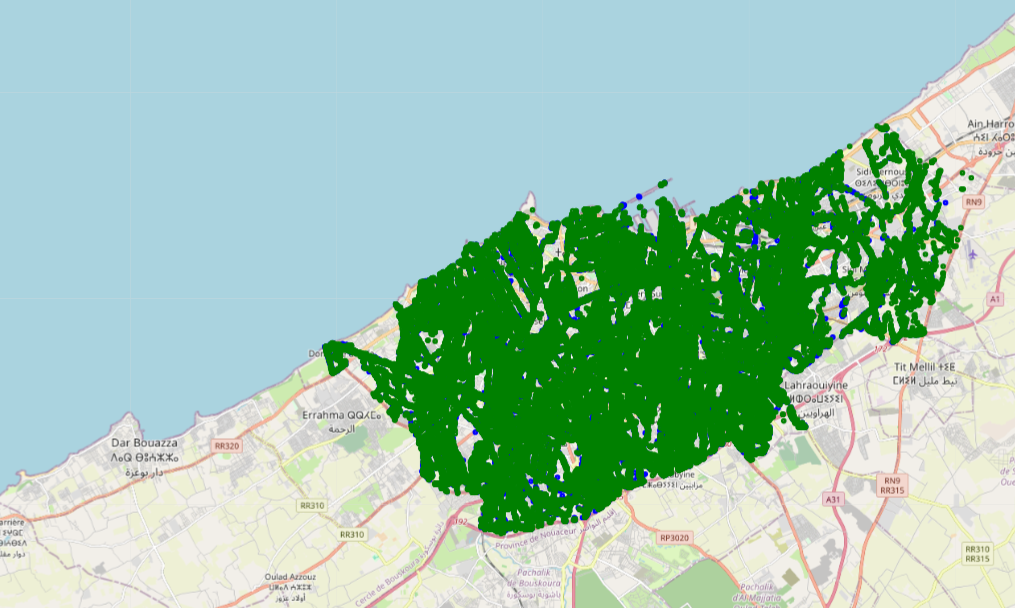

## **STEP 24 — Ajouter les arrondissements sur la carte**


- Tracer les polygones des arrondissements avec :

          contours visibles
          transparence
          nom affiché au survol

In [ ]:
print(zones_gdf.columns)

Index(['Prefecture', 'Population', 'Superficie', 'Arrondissement', 'geometry'], dtype='object')


In [ ]:
# STEP 24 — Affichage des arrondissements (fix final)

# 🔥 recréer la carte (évite conflits anciens layers)
m2 = folium.Map(location=[33.57, -7.62], zoom_start=11)

# 🔹 Sample points
pdf_sample = pdf_filtered.sample(n=500, random_state=42)

# Origine
for _, row in pdf_sample.iterrows():
    folium.CircleMarker(
        location=[row["origin_lat_casa"], row["origin_lon_casa"]],
        radius=2,
        color="red"
    ).add_to(m2)

# Destination
for _, row in pdf_sample.iterrows():
    folium.CircleMarker(
        location=[row["destination_lat_casa"], row["destination_lon_casa"]],
        radius=2,
        color="green"
    ).add_to(m2)

# 🔹 Ajout des arrondissements
# STEP 24 — VERSION FIX TOOLTIP

folium.GeoJson(
    zones_gdf,

    style_function=lambda feature: {
        'fillColor': 'blue',     # 🔥 important
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.1       # 🔥 transparent mais détectable
    },

    tooltip=folium.GeoJsonTooltip(
        fields=['Arrondissement'],
        aliases=['Arrondissement:'],
        sticky=True              # 🔥 important
    )

).add_to(m2)


m2


# **Reconstitution des trajets**

In [ ]:
# STEP 25 — Sample 10 trajets avec POLYLINE complète

df_trips_sample = df_parsed.select(
    "TRIP_ID",
    "polyline_array"
).limit(10)

pdf_trips = df_trips_sample.toPandas()

print("Nombre de trajets sélectionnés :", len(pdf_trips))

Nombre de trajets sélectionnés : 10


In [ ]:
# STEP 26 — Transformation de toute la trajectoire

def transform_polyline(polyline):
    transformed = []

    for point in polyline:
        lon, lat = point

        lat_casa = ((lat - porto_lat_min) / (porto_lat_max - porto_lat_min)) \
                   * (casa_lat_max - casa_lat_min) + casa_lat_min

        lon_casa = ((lon - porto_lon_min) / (porto_lon_max - porto_lon_min)) \
                   * (casa_lon_max - casa_lon_min) + casa_lon_min

        transformed.append([lat_casa, lon_casa])

    return transformed


pdf_trips["trajectory_casa"] = pdf_trips["polyline_array"].apply(transform_polyline)

print("Transformation terminée")


Transformation terminée


In [ ]:
# STEP 27 — Visualisation des trajets complets

import folium

m3 = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_trips.iterrows():

    traj = row["trajectory_casa"]

    # 🔴 ORIGIN
    folium.Marker(
        location=traj[0],
        icon=folium.Icon(color="red"),
        popup="Origin"
    ).add_to(m3)

    # 🟢 DESTINATION
    folium.Marker(
        location=traj[-1],
        icon=folium.Icon(color="green"),
        popup="Destination"
    ).add_to(m3)

    # 🔵 TRAJET COMPLET
    folium.PolyLine(
        locations=traj,
        color="blue",
        weight=3,
        opacity=0.7
    ).add_to(m3)

    # ⚫ POINTS INTERMEDIAIRES (SANS MARKER)
    for point in traj:
        folium.CircleMarker(
            location=point,
            radius=1,
            color="black",
            fill=True,
            fill_opacity=0.5
        ).add_to(m3)

m3


In [ ]:
# STEP 25 — Sample de trajets complets

df_trips_sample = df_parsed.select(
    "TRIP_ID",
    "polyline_array"
).limit(100)  # on prend 50 pour filtrer ensuite

pdf_trips = df_trips_sample.toPandas()

print("Trajets chargés :", len(pdf_trips))


Trajets chargés : 100


In [ ]:
# STEP 26 — Transformation complète des trajectoires

def transform_polyline(polyline):
    transformed = []

    for point in polyline:
        lon, lat = point

        lat_casa = ((lat - porto_lat_min) / (porto_lat_max - porto_lat_min)) \
                   * (casa_lat_max - casa_lat_min) + casa_lat_min

        lon_casa = ((lon - porto_lon_min) / (porto_lon_max - porto_lon_min)) \
                   * (casa_lon_max - casa_lon_min) + casa_lon_min

        transformed.append((lon_casa, lat_casa))  # shapely = (lon, lat)

    return transformed


pdf_trips["trajectory_casa"] = pdf_trips["polyline_array"].apply(transform_polyline)

print("Transformation OK")


Transformation OK


In [ ]:
# STEP 27 — Filtrer trajets entièrement dans Casablanca

def is_trip_inside(traj):
    for lon, lat in traj:
        point = Point(lon, lat)

        if not casablanca_polygon.contains(point):
            return False

    return True


pdf_trips["inside_casa"] = pdf_trips["trajectory_casa"].apply(is_trip_inside)

pdf_trips_filtered = pdf_trips[pdf_trips["inside_casa"] == True]

print("Trajets valides :", len(pdf_trips_filtered))


Trajets valides : 17


In [ ]:
def is_trip_mostly_inside(traj):
    inside_count = 0

    for lon, lat in traj:
        if casablanca_polygon.contains(Point(lon, lat)):
            inside_count += 1

    return inside_count / len(traj) > 0.8


In [ ]:
# STEP 28 — Sélection finale

pdf_final_trips = pdf_trips_filtered.head(10)

print("Trajets pour visualisation :", len(pdf_final_trips))


Trajets pour visualisation : 10


In [ ]:
# STEP 29 — Visualisation des trajets filtrés

import folium

m4 = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_final_trips.iterrows():

    traj = [(lat, lon) for lon, lat in row["trajectory_casa"]]  # folium = (lat, lon)

    # 🔴 ORIGIN
    folium.Marker(
        location=traj[0],
        icon=folium.Icon(color="red")
    ).add_to(m4)

    # 🟢 DESTINATION
    folium.Marker(
        location=traj[-1],
        icon=folium.Icon(color="green")
    ).add_to(m4)

    # 🔵 TRAJET COMPLET
    folium.PolyLine(
        locations=traj,
        color="red",
        weight=3
    ).add_to(m4)

    # ⚫ POINTS INTERMEDIAIRES
    for point in traj[::2]:  # optimisation
        folium.CircleMarker(
            location=point,
            radius=1,
            color="black",
            fill=True
        ).add_to(m4)
# STEP — Affichage des arrondissements (contours uniquement)

folium.GeoJson(
    zones_gdf,

    style_function=lambda feature: {
        'fillOpacity': 0,   # 🔥 pas de remplissage
        'color': 'blue',    # couleur des contours
        'weight': 2         # épaisseur des bordures
    },

    tooltip=folium.GeoJsonTooltip(
        fields=['Arrondissement'],
        aliases=['Arrondissement:'],
        sticky=True
    )

).add_to(m4)   # ou m2 selon ta map



m4


In [ ]:
# STEP 29 — Visualisation des trajets filtrés

import folium

m4 = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_final_trips.iterrows():

    traj = [(lat, lon) for lon, lat in row["trajectory_casa"]]  # folium = (lat, lon)

    # 🔴 ORIGIN
    folium.Marker(
        location=traj[0],
        icon=folium.Icon(color="red")
    ).add_to(m4)

    # 🟢 DESTINATION
    folium.Marker(
        location=traj[-1],
        icon=folium.Icon(color="green")
    ).add_to(m4)

    # 🔵 TRAJET COMPLET
    folium.PolyLine(
        locations=traj,
        color="blue",
        weight=3
    ).add_to(m4)

    # ⚫ POINTS INTERMEDIAIRES
    for point in traj[::2]:  # optimisation
        folium.CircleMarker(
            location=point,
            radius=1,
            color="black",
            fill=True
        ).add_to(m4)




m4


# **Conclusion - Remapping & Visualisation des trajets**


---


Dans ce travail, nous avons exploré trois approches successives pour transformer et visualiser le dataset de Porto dans le contexte de Casablanca.

## **1. Approche 1 — Bounding Box sans filtrage**

- Principe :

Transformation linéaire des coordonnées GPS Porto → Casablanca
Aucune validation spatiale
- Avantages
Simple à implémenter
Rapide à exécuter
Permet une première visualisation globale
- Limites
Présence de nombreux points en dehors de Casablanca (océan, zones rurales)
Données géographiquement incohérentes
Résultat peu réaliste
## **2. Approche 1 améliorée — Bounding Box avec filtrage**

- Principe :

Transformation GPS
Filtrage basé sur la bounding box (clamp ou suppression)
- Avantages
Réduction des points aberrants
Amélioration visuelle par rapport à l’approche précédente
- Limites
Les zones restent artificielles (grille uniforme 4×4)
Ne reflètent pas les vrais arrondissements
Certains trajets restent partiellement hors Casablanca
Approximation géographique encore limitée
## **3. Approche 2 — GeoJSON (arrondissements réels)**

- Principe :

Utilisation d’un fichier GeoJSON contenant les polygones réels des arrondissements
Filtrage spatial avec test : point ∈ Casablanca
- Avantages
Résultat géographiquement précis et réaliste
Trajets cohérents avec les limites urbaines réelles
Visualisation fidèle (trajets + arrondissements)
Approche alignée avec les pratiques professionnelles
- Limite principale
Seulement ~20% des trajets conservés
due au filtrage strict (points hors Casablanca supprimés)
perte importante de volume de données
## **Conclusion générale**
L’approche Bounding Box permet une première simulation rapide mais reste approximative.
L’ajout de filtrage améliore légèrement la qualité sans résoudre le problème de réalisme.
L’approche GeoJSON offre une solution robuste et réaliste, au prix d’une réduction significative du dataset.

Ainsi, un compromis doit être trouvé entre :

- volume de données (quantité)
- qualité géographique (réalisme)


---

## **Ouverture**

“Future improvements could include relaxing the filtering constraint (e.g., keeping trajectories mostly inside Casablanca) or enriching the dataset using synthetic augmentation to compensate for data loss.”


# **Partie 2 : Map - Matching**

Objectif :
- Mettre les trajets compatibles avec le graph routier de Casablanca

Résultat souhaité :    
- Tous les trajets suivent les vrais routes de Casablanca, avec optimisation du trajet le plus rapide

# **Approche 1 : OSMNX + NetworkX**

In [ ]:

!pip install osmnx networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.5 MB/s eta 0:00:00


In [ ]:

import osmnx as ox
import networkx as nx
import pandas as pd
from shapely.geometry import LineString

In [ ]:
G = ox.graph_from_place("Casablanca, Morocco", network_type="drive")

print("Graphe chargé :", len(G.nodes), "noeuds,", len(G.edges), "arêtes")

Graphe chargé : 37579 noeuds, 99354 arêtes


In [ ]:
ox.save_graphml(G, "/content/drive/MyDrive/casablanca.graphml")

In [ ]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [ ]:
G = ox.load_graphml("/content/drive/MyDrive/casablanca.graphml")

In [ ]:
# STEP 3 — Utiliser trajets filtrés

pdf_trips_clean = pdf_trips_filtered.dropna(subset=["trajectory_casa"])

# sample
pdf_trips_sample = pdf_trips_clean.head(1)

print("Trajets utilisés :", len(pdf_trips_sample))

Trajets utilisés : 1


In [ ]:
def snap_points_to_nodes(G, polyline):
    nodes = []

    for lon, lat in polyline:
        try:
            node = ox.distance.nearest_nodes(G, lon, lat)
            nodes.append(node)
        except:
            continue

    return nodes


In [ ]:
def reconstruct_route(G, nodes):
    full_route = []

    for i in range(len(nodes) - 1):
        try:
            segment = nx.shortest_path(
                G,
                nodes[i],
                nodes[i+1],
                weight="length"
            )
            full_route.extend(segment)
        except:
            continue

    return full_route

In [ ]:
def nodes_to_coords(G, route_nodes):
    coords = []

    for node in route_nodes:
        lon = G.nodes[node]["x"]
        lat = G.nodes[node]["y"]
        coords.append((lon, lat))

    return coords

In [ ]:
def process_trip(G, polyline):



    nodes = snap_points_to_nodes(G, polyline)

    if len(nodes) < 2:
        return None

    route_nodes = reconstruct_route(G, nodes)

    if len(route_nodes) == 0:
        return None

    coords = nodes_to_coords(G, route_nodes)

    return coords


In [ ]:
pdf_trips_sample["real_route"] = pdf_trips_sample["trajectory_casa"].apply(
    lambda poly: process_trip(G, poly)
)

print("Transformation terminée")

Transformation terminée


/tmp/ipykernel_16310/2429917876.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf_trips_sample["real_route"] = pdf_trips_sample["trajectory_casa"].apply(


In [ ]:
import folium

m = folium.Map(location=[33.57, -7.62], zoom_start=12)

row = pdf_trips_sample.iloc[0]

original = row["trajectory_casa"]
real_route = row["real_route"]

# 🔴 TRAJET ORIGINAL (FAUX)
orig_latlon = [(lat, lon) for lon, lat in original]

folium.PolyLine(
    orig_latlon,
    color="red",
    weight=4,
    opacity=0.6,
    tooltip="Original (faux)"
).add_to(m)

# 🔵 TRAJET RÉEL (MAP MATCHED)
if real_route:
    real_latlon = [(lat, lon) for lon, lat in real_route]

    folium.PolyLine(
        real_latlon,
        color="green",
        weight=4,
        opacity=0.8,
        tooltip="Map-matched (réel)"
    ).add_to(m)

# ORIGIN
folium.Marker(
    location=real_route[0],
    icon=folium.Icon(color="green"),
    tooltip="Origin"
).add_to(m)

# DESTINATION
folium.Marker(
    location=real_route[-1],
    icon=folium.Icon(color="red"),
    tooltip="Destination"
).add_to(m)


# 📍 Origin / Destination
folium.Marker(
    location=orig_latlon[0],
    icon=folium.Icon(color="purple"),
    popup="Origin"
).add_to(m)

folium.Marker(
    location=orig_latlon[-1],
    icon=folium.Icon(color="red"),
    popup="Destination"
).add_to(m)

# # 🟦 ARRONDISSEMENTS CASA
# folium.GeoJson(
#     zones_gdf,
#     style_function=lambda feature: {
#         'fillColor': 'blue',
#         'color': 'blue',
#         'weight': 2,
#         'fillOpacity': 0.1
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=['Arrondissement'],
#         aliases=['Arrondissement:']
#     )
# ).add_to(m)

m

# **Approche 2 :**

In [ ]:
# STEP 1 — Imports

import requests
import pandas as pd
import folium


In [ ]:
# STEP 2 — Nettoyage + sample

pdf_trips_clean = pdf_trips_filtered.dropna(subset=["trajectory_casa"])

pdf_trips_sample = pdf_trips_clean.head(1).copy()

print("Nombre de trajets test :", len(pdf_trips_sample))


Nombre de trajets test : 1


In [ ]:
# STEP 3 — Fonction OSRM

def osrm_map_match(polyline):

    if polyline is None or len(polyline) < 2:
        return None

    # 🔥 réduire points (important)
    polyline = polyline[::5]

    coords = ";".join([f"{lon},{lat}" for lon, lat in polyline])

    url = f"http://router.project-osrm.org/match/v1/driving/{coords}?geometries=geojson"

    try:
        response = requests.get(url)
        data = response.json()

        if "matchings" in data and len(data["matchings"]) > 0:
            return data["matchings"][0]["geometry"]["coordinates"]

        return None

    except:
        return None


In [ ]:
# STEP 4 — Map matching

pdf_trips_sample["real_route_osrm"] = pdf_trips_sample["trajectory_casa"].apply(
    lambda poly: osrm_map_match(poly)
)

print("Map matching terminé")


Map matching terminé


In [ ]:
# STEP 5 — Vérifier résultats

print(pdf_trips_sample["trajectory_casa"].head(3))


1    [(-7.645960901781492, 33.53568772528933), (-7....
Name: trajectory_casa, dtype: object


In [ ]:
print(pdf_trips_sample["real_route_osrm"].head(3))

1    [[-7.645961, 33.535688], [-7.646447, 33.53515]...
Name: real_route_osrm, dtype: object


In [ ]:
# STEP 6 — Visualisation comparaison

m = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_trips_sample.iterrows():

    # 🔴 AVANT
    traj_before = [(lat, lon) for lon, lat in row["trajectory_casa"]]

    folium.PolyLine(
        locations=traj_before,
        color="red",
        weight=2,
        tooltip="Avant"
    ).add_to(m)

    # 🟢 APRÈS
    route = row["real_route_osrm"]

    if route is not None:
        traj_after = [(lat, lon) for lon, lat in route]

        folium.PolyLine(
            locations=traj_after,
            color="green",
            weight=4,
            tooltip="Après OSRM"
        ).add_to(m)

    # 🔵 ORIGIN
    folium.Marker(
        location=traj_before[0],
        icon=folium.Icon(color="blue")
    ).add_to(m)

    # 🟣 DESTINATION
    folium.Marker(
        location=traj_before[-1],
        icon=folium.Icon(color="purple")
    ).add_to(m)

#     # # # Arrondissements Casa

#     # # folium.GeoJson(
#     # # zones_gdf,
#     # # style_function=lambda feature: {
#     # #     'fillOpacity': 0,
#     # #     'color': 'blue',
#     # #     'weight': 2
#     # }
# ).add_to(m)


m


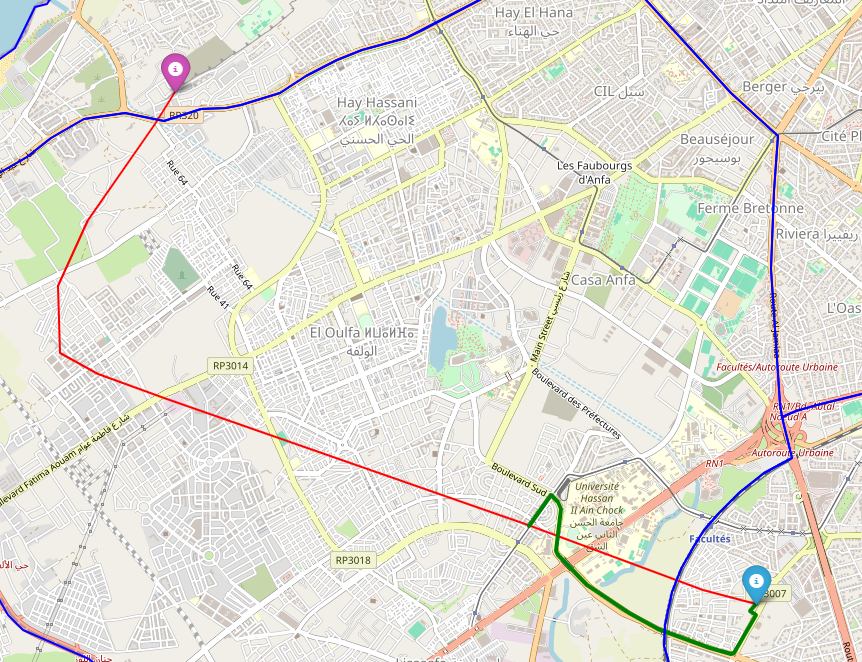

# **Approche 3 :**

In [ ]:
# STEP 1 — Imports

import requests
import pandas as pd
import folium


In [ ]:
# STEP 2 — Nettoyage + sample

pdf_trips_clean = pdf_trips_filtered.dropna(subset=["trajectory_casa"])

pdf_trips_sample = pdf_trips_clean.head(2).copy()

print("Nombre de trajets test :", len(pdf_trips_sample))


Nombre de trajets test : 2


In [ ]:
# STEP 3 — OSRM amélioré (match + route)

def osrm_map_match(polyline):

    if polyline is None or len(polyline) < 2:
        return None

    polyline = polyline[::5]  # réduire bruit

    coords = ";".join([f"{lon},{lat}" for lon, lat in polyline])

    url = f"http://router.project-osrm.org/match/v1/driving/{coords}?geometries=geojson"

    try:
        response = requests.get(url)
        data = response.json()

        if "matchings" in data and len(data["matchings"]) > 0:
            return data["matchings"][0]["geometry"]["coordinates"]

        return None

    except:
        return None


def osrm_route(start, end):

    coords = f"{start[0]},{start[1]};{end[0]},{end[1]}"

    url = f"http://router.project-osrm.org/route/v1/driving/{coords}?geometries=geojson"

    try:
        res = requests.get(url).json()

        return res["routes"][0]["geometry"]["coordinates"]

    except:
        return None


def osrm_full_pipeline(polyline):

    if polyline is None or len(polyline) < 2:
        return None

    polyline_reduced = polyline[::5]

    matched = osrm_map_match(polyline_reduced)

    if matched is None or len(matched) == 0:
        return None

    # 🔥 forcer arrivée correcte
    last_matched_point = matched[-1]
    true_destination = polyline[-1]

    last_segment = osrm_route(last_matched_point, true_destination)

    if last_segment:
        matched.extend(last_segment)

    return matched


In [ ]:
# STEP 4 — Debug propre

routes = []

for poly in pdf_trips_sample["trajectory_casa"]:
    route = osrm_map_match(poly)
    print("Route trouvée :", route is not None)
    routes.append(route)

pdf_trips_sample["real_route_osrm"] = routes



Route trouvée : True
Route trouvée : False


In [ ]:
print(pdf_trips_sample["real_route_osrm"])


1     [[-7.645961, 33.535688], [-7.646447, 33.53515]...
19                                                 None
Name: real_route_osrm, dtype: object


In [ ]:
print(pdf_trips_sample[["trajectory_casa", "real_route_osrm"]].head(3))


                                      trajectory_casa  \
1   [(-7.645960901781492, 33.53568772528933), (-7....   
19  [(-7.6535913605549455, 33.56655852779359), (-7...   

                                      real_route_osrm  
1   [[-7.645961, 33.535688], [-7.646447, 33.53515]...  
19                                               None  


In [ ]:
# STEP 6 — Visualisation comparaison

m = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_trips_sample.iterrows():

    # 🔴 AVANT
    traj_before = [(lat, lon) for lon, lat in row["trajectory_casa"]]

    folium.PolyLine(
        locations=traj_before,
        color="red",
        weight=2,
        tooltip="Avant"
    ).add_to(m)

    # 🟢 APRÈS
    route = row["real_route_osrm"]

    if route is not None and len(route) > 0:
        traj_after = [(lat, lon) for lon, lat in route]

        folium.PolyLine(
            locations=traj_after,
            color="green",
            weight=4,
            tooltip="Après OSRM"
        ).add_to(m)

    # 🔵 ORIGIN
    folium.Marker(
        location=traj_before[0],
        icon=folium.Icon(color="blue")
    ).add_to(m)

    # 🟣 DESTINATION
    folium.Marker(
        location=traj_before[-1],
        icon=folium.Icon(color="purple")
    ).add_to(m)


    # 🔵 ORIGIN
    folium.Marker(
        location=traj_after[0],
        icon=folium.Icon(color="blue")
    ).add_to(m)

    # 🟣 DESTINATION
    folium.Marker(
        location=traj_after[-1],
        icon=folium.Icon(color="purple")
    ).add_to(m)
m


# **Approche 4 :**

In [ ]:
# STEP 3 — OSRM robuste (match + correction début + fin)

def osrm_map_match(polyline):


    coords = ";".join([f"{lon},{lat}" for lon, lat in polyline])

    url = f"http://router.project-osrm.org/match/v1/driving/{coords}?geometries=geojson"

    try:
        res = requests.get(url).json()

        if "matchings" in res and len(res["matchings"]) > 0:
            return res["matchings"][0]["geometry"]["coordinates"]

        return None

    except:
        return None


def osrm_route(start, end):

    coords = f"{start[0]},{start[1]};{end[0]},{end[1]}"

    url = f"http://router.project-osrm.org/route/v1/driving/{coords}?geometries=geojson"

    try:
        res = requests.get(url).json()
        return res["routes"][0]["geometry"]["coordinates"]

    except:
        return None


def osrm_full_pipeline_v4(polyline):

    if polyline is None or len(polyline) < 2:
        return None

    original_start = polyline[0]
    original_end = polyline[-1]

    matched = osrm_map_match(polyline)

    # ❌ fallback si match échoue
    if matched is None or len(matched) < 2:
        return osrm_route(original_start, original_end)

    final_route = []

    # 🔵 1. forcer début
    first_matched = matched[0]
    start_segment = osrm_route(original_start, first_matched)

    if start_segment:
        final_route.extend(start_segment)

    # 🟢 2. trajet principal
    final_route.extend(matched)

    # 🔴 3. forcer fin
    last_matched = matched[-1]
    end_segment = osrm_route(last_matched, original_end)

    if end_segment:
        final_route.extend(end_segment)

    return final_route


In [ ]:
pdf_trips_sample.loc[:, "real_route_osrm"] = pdf_trips_sample["trajectory_casa"].apply(
    lambda poly: osrm_full_pipeline(poly)
)


In [ ]:
# STEP 6 — Visualisation comparaison

m = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_trips_sample.iterrows():

    # 🔴 AVANT
    traj_before = [(lat, lon) for lon, lat in row["trajectory_casa"]]

    folium.PolyLine(
        locations=traj_before,
        color="red",
        weight=2,
        tooltip="Avant"
    ).add_to(m)

    # 🟢 APRÈS
    route = row["real_route_osrm"]

    if route is not None and len(route) > 0:
        traj_after = [(lat, lon) for lon, lat in route]

        folium.PolyLine(
            locations=traj_after,
            color="green",
            weight=4,
            tooltip="Après OSRM"
        ).add_to(m)

    # 🔵 ORIGIN
    folium.Marker(
        location=traj_before[0],
        icon=folium.Icon(color="blue")
    ).add_to(m)

    # 🟣 DESTINATION
    folium.Marker(
        location=traj_before[-1],
        icon=folium.Icon(color="purple")
    ).add_to(m)


    # 🔵 ORIGIN
    folium.Marker(
        location=traj_after[0],
        icon=folium.Icon(color="blue")
    ).add_to(m)

    # 🟣 DESTINATION
    folium.Marker(
        location=traj_after[-1],
        icon=folium.Icon(color="purple")
    ).add_to(m)
m


# **Approche 5 : ORSM**

In [ ]:
import requests
import pandas as pd
import folium
from math import radians, cos, sin, sqrt, atan2

In [ ]:
def haversine(coord1, coord2):
    lon1, lat1 = coord1
    lon2, lat2 = coord2

    R = 6371  # km

    dlon = radians(lon2 - lon1)
    dlat = radians(lat2 - lat1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [ ]:
def adaptive_sampling(polyline):
    n = len(polyline)

    if n < 50:
        return polyline
    elif n < 200:
        return polyline[::3]
    elif n < 500:
        return polyline[::2]
    else:
        return polyline[::2]  # garder plus de points pour long trajet

In [ ]:
def chunk_polyline(polyline, chunk_size=80):
    chunks = []

    for i in range(0, len(polyline), chunk_size):
        chunk = polyline[i:i+chunk_size]

        if len(chunk) >= 2:
            chunks.append(chunk)

    return chunks

In [ ]:
def osrm_map_match(polyline):

    coords = ";".join([f"{lon},{lat}" for lon, lat in polyline])

    radiuses = ";".join(["40"] * len(polyline))  # tolérance 40m

    url = f"http://router.project-osrm.org/match/v1/driving/{coords}?geometries=geojson&radiuses={radiuses}"

    try:
        res = requests.get(url).json()

        if "matchings" in res and len(res["matchings"]) > 0:
            return res["matchings"][0]["geometry"]["coordinates"]

        return None

    except:
        return None

In [ ]:
def osrm_route(start, end):

    coords = f"{start[0]},{start[1]};{end[0]},{end[1]}"

    url = f"http://router.project-osrm.org/route/v1/driving/{coords}?geometries=geojson"

    try:
        res = requests.get(url).json()
        return res["routes"][0]["geometry"]["coordinates"]

    except:
        return None

In [ ]:
def osrm_full_pipeline_v2(polyline):

    if polyline is None or len(polyline) < 2:
        return None

    # 🔵 1. sampling intelligent
    sampled = adaptive_sampling(polyline)

    # 🔵 2. split en chunks
    chunks = chunk_polyline(sampled)

    final_route = []

    for chunk in chunks:

        matched = osrm_map_match(chunk)

        # 🟡 fallback si match échoue
        if matched is None or len(matched) < 2:
            route = osrm_route(chunk[0], chunk[-1])

            if route:
                final_route.extend(route)

        else:
            final_route.extend(matched)

    # 🔴 3. validation finale (sécurité)
    if len(final_route) < 2:
        return osrm_route(polyline[0], polyline[-1])

    return final_route


In [ ]:
pdf_trips_clean = pdf_trips_filtered.dropna(subset=["trajectory_casa"])

pdf_trips_sample = pdf_trips_clean.head(3).copy()

pdf_trips_sample["real_route_osrm"] = pdf_trips_sample["trajectory_casa"].apply(
    lambda poly: osrm_full_pipeline_v2(poly)
)

In [ ]:
m = folium.Map(location=[33.57, -7.62], zoom_start=12)

for _, row in pdf_trips_sample.iterrows():

    traj_before = [(lat, lon) for lon, lat in row["trajectory_casa"]]

    folium.PolyLine(
        locations=traj_before,
        color="red",
        weight=2,
        tooltip="Avant"
    ).add_to(m)

    route = row["real_route_osrm"]

    if route is not None and len(route) > 0:
        traj_after = [(lat, lon) for lon, lat in route]

        folium.PolyLine(
            locations=traj_after,
            color="green",
            weight=4,
            tooltip="Après (corrigé)"
        ).add_to(m)

        folium.Marker(location=traj_after[0], icon=folium.Icon(color="blue")).add_to(m)
        folium.Marker(location=traj_after[-1], icon=folium.Icon(color="purple")).add_to(m)

# 🟦 ARRONDISSEMENTS CASA
folium.GeoJson(
    zones_gdf,
    style_function=lambda feature: {
        'fillColor': 'blue',
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Arrondissement'],
        aliases=['Arrondissement:']
    )
).add_to(m)
m

# **Comparaison de toutes les approches en fixant un trajet représentatif**

In [ ]:
# Nettoyage
pdf_trips_clean = pdf_trips_filtered.dropna(subset=["trajectory_casa"])

# 🔥 choisir un seul trajet
row = pdf_trips_clean.iloc[0]
polyline = row["trajectory_casa"]

print("Nombre de points :", len(polyline))


Nombre de points : 19


In [ ]:
import folium

m = folium.Map(location=[33.57, -7.62], zoom_start=13)

# 🔴 Original
orig = [(lat, lon) for lon, lat in polyline]
folium.PolyLine(orig, color="red", weight=4, tooltip="Original").add_to(m)

folium.Marker(
    orig_latlon[0],
    tooltip="Départ",
    icon=folium.Icon(color="green", icon="play", prefix="fa")
).add_to(m)

folium.Marker(
    orig_latlon[-1],
    tooltip="Arrivée",
    icon=folium.Icon(color="red", icon="stop", prefix="fa")
).add_to(m)
folium.GeoJson(
    zones_gdf,
    style_function=lambda feature: {
        'fillColor': 'blue',
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Arrondissement'],
        aliases=['Arrondissement:']
    )
).add_to(m)

m

In [ ]:
route1 = process_trip(G, polyline)
print("Approche 1 terminée")


Approche 1 terminée


In [ ]:
route2 = osrm_map_match(polyline)
print("Approche 2 terminée")


Approche 2 terminée


In [ ]:
print("Route 2:", route2)
print("Type:", type(route2))
print("Longueur:", len(route2) if route2 else "None")


Route 2: None
Type: <class 'NoneType'>
Longueur: None


In [ ]:
route3 = osrm_full_pipeline(polyline)
print("Approche 3 terminée")


Approche 3 terminée


In [ ]:
route4 = osrm_full_pipeline_v4(polyline)
print("Approche 4 terminée")


Approche 4 terminée


In [ ]:
route5 = osrm_full_pipeline_v2(polyline)
print("Approche 5 terminée")

Approche 5 terminée


In [ ]:
import folium
import pandas as pd
from math import dist

# ------------------------------------------------------------
# 1. Initialisation de la carte
# ------------------------------------------------------------
m = folium.Map(location=[33.57, -7.62], zoom_start=13)

# ------------------------------------------------------------
# 2. Création des FeatureGroup (un par approche)
# ------------------------------------------------------------
fg_orig = folium.FeatureGroup(name="🔴 Original (brut)")
fg_app1 = folium.FeatureGroup(name="🟢 Approche 1 – OSMnx")
fg_app2 = folium.FeatureGroup(name="⚫ Approche 2 – OSRM simple")
fg_app3 = folium.FeatureGroup(name="🔵 Approche 3 – + correction fin")
fg_app4 = folium.FeatureGroup(name="🟠 Approche 4 – + correction début/fin")
fg_app5 = folium.FeatureGroup(name="🟣 Approche 5 – Avancée (chunks + radius)")

# ------------------------------------------------------------
# 3. Conversion des coordonnées (lon, lat) -> (lat, lon)
# ------------------------------------------------------------
orig_latlon = [(lat, lon) for lon, lat in polyline]

def to_latlon(route):
    """Convertit une route [(lon,lat), ...] en [(lat,lon), ...] pour Folium."""
    if route is None:
        return None
    return [(lat, lon) for lon, lat in route]

r1 = to_latlon(route1)
r2 = to_latlon(route2)
r3 = to_latlon(route3)
r4 = to_latlon(route4)
r5 = to_latlon(route5)

# ------------------------------------------------------------
# 4. Ajout des tracés dans les FeatureGroup
# ------------------------------------------------------------
# Original
folium.PolyLine(
    orig_latlon,
    color="red",
    weight=3,
    opacity=0.5,
    tooltip="Trajet original (projection brute)"
).add_to(fg_orig)

# Approche 1
if r1:
    folium.PolyLine(r1, color="green", weight=4, opacity=0.8, tooltip="OSMnx").add_to(fg_app1)

# Approche 2
if r2:
    folium.PolyLine(r2, color="black", weight=4, opacity=0.8, tooltip="OSRM simple").add_to(fg_app2)

# Approche 3
if r3:
    folium.PolyLine(r3, color="blue", weight=4, opacity=0.8, tooltip="OSRM + fin").add_to(fg_app3)

# Approche 4
if r4:
    folium.PolyLine(r4, color="orange", weight=4, opacity=0.8, tooltip="OSRM + début/fin").add_to(fg_app4)

# Approche 5
if r5:
    folium.PolyLine(r5, color="purple", weight=4, opacity=0.8, tooltip="OSRM avancé").add_to(fg_app5)

# ------------------------------------------------------------
# 5. Marqueurs Origine / Destination (corrigés)
# ------------------------------------------------------------
folium.Marker(
    orig_latlon[0],
    tooltip="Départ",
    icon=folium.Icon(color="green", icon="play", prefix="fa")
).add_to(m)

folium.Marker(
    orig_latlon[-1],
    tooltip="Arrivée",
    icon=folium.Icon(color="red", icon="stop", prefix="fa")
).add_to(m)

# ------------------------------------------------------------
# 6. Ajout des arrondissements (GeoJSON)
# ------------------------------------------------------------
# folium.GeoJson(
#     zones_gdf,
#     name="Arrondissements Casa",
#     style_function=lambda feature: {
#         'fillColor': 'blue',
#         'color': 'blue',
#         'weight': 2,
#         'fillOpacity': 0.1
#     },
#     tooltip=folium.GeoJsonTooltip(
#         fields=['Arrondissement'],
#         aliases=['Arrondissement:']
#     )
# ).add_to(m)

# ------------------------------------------------------------
# 7. Ajout de tous les FeatureGroup à la carte
# ------------------------------------------------------------
fg_orig.add_to(m)
fg_app1.add_to(m)
fg_app2.add_to(m)
fg_app3.add_to(m)
fg_app4.add_to(m)
fg_app5.add_to(m)

# ------------------------------------------------------------
# 8. Contrôle des couches (LayerControl)
# ------------------------------------------------------------
folium.LayerControl(collapsed=False).add_to(m)

# ------------------------------------------------------------
# 9. Affichage de la carte
# ------------------------------------------------------------
display(m)

# # ------------------------------------------------------------
# # 10. Tableau statistique : nombre de points et longueur
# # ------------------------------------------------------------
# def route_length_km(route):
#     """Calcule la longueur approximative en km d'une route [(lon, lat), ...]."""
#     if route is None:
#         return None
#     total = 0.0
#     for i in range(len(route) - 1):
#         # Approximation : 1 degré ≈ 111 km à l'équateur
#         dx = (route[i+1][0] - route[i][0]) * 111.0
#         dy = (route[i+1][1] - route[i][1]) * 111.0
#         total += (dx**2 + dy**2) ** 0.5
#     return round(total, 2)

# stats = []
# for name, route in [
#     ("Original", polyline),
#     ("Approche 1", route1),
#     ("Approche 2", route2),
#     ("Approche 3", route3),
#     ("Approche 4", route4),
#     ("Approche 5", route5)
# ]:
#     if route:
#         nb_points = len(route)
#         longueur = route_length_km(route)
#         stats.append({
#             "Approche": name,
#             "Nb points": nb_points,
#             "Longueur (km)": longueur
#         })
#     else:
#         stats.append({
#             "Approche": name,
#             "Nb points": "Échec",
#             "Longueur (km)": "Échec"
#         })

# df_stats = pd.DataFrame(stats)
# print("📊 Statistiques des trajets :")
# display(df_stats)

# **Conclusion : Map Matching**


---


- Plusieurs approches de map-matching ont été étudiées afin de reconstruire des trajectoires réalistes à partir de données GPS bruitées.
- Mais, Deux approches principales de map-matching ont été étudiées :



```
    - une approche basée sur OSMnx et NetworkX,
    - une approche basée sur OSRM.
```

- **Approche 1 :**
    - la projection des points GPS vers le réseau routier
    - le calcul du plus court chemin entre points consécutifs
    - Cette méthode reste simple et rapide, mais présente plusieurs limites :
zigzags,
détours incohérents,
absence d’optimisation globale de la trajectoire.


- **Approche 2 :**
     - génère plusieurs candidats pour chaque point GPS
     - sélectionne la trajectoire la plus cohérente globalement à l’aide de scores de proximité et de transition.

- Plusieurs améliorations ont également été testées :
     - sampling adaptatif,
     - correction du début et de la fin des trajets,
     - découpage en segments,

- Les résultats obtenus montrent que les approches basées sur **OSRM** produisent des trajectoires plus réalistes, plus stables et mieux alignées avec le réseau routier réel.